In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

RUTA = "/content/drive/MyDrive/Proyecto/Anemia Diagnosis Dataset - Complete blood count.csv"
CARPETA = "/content/drive/MyDrive/Proyecto"

df = pd.read_csv("/content/drive/MyDrive/Proyecto/Anemia Diagnosis Dataset - Complete blood count.csv")
df.columns = df.columns.str.strip()
df = df.iloc[1:].copy()
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna(how="all").reset_index(drop=True)
df = df.rename(columns={"S. No.": "id", "PLT /mm3": "PLT"})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      364 non-null    float64
 1   Age     364 non-null    float64
 2   Sex     364 non-null    float64
 3   RBC     364 non-null    float64
 4   PCV     364 non-null    float64
 5   MCV     364 non-null    float64
 6   MCH     364 non-null    float64
 7   MCHC    364 non-null    float64
 8   RDW     364 non-null    float64
 9   TLC     364 non-null    float64
 10  PLT     364 non-null    float64
 11  HGB     364 non-null    float64
dtypes: float64(12)
memory usage: 34.3 KB


In [6]:
# Variable: diagnóstico de anemia (OMS: HGB<13 varones, HGB<12 mujeres)
# Sex: 0=varón, 1=mujer (inferido; ver README)
df["anemia"] = np.where(
    ((df["Sex"] == 0) & (df["HGB"] < 13)) |
    ((df["Sex"] == 1) & (df["HGB"] < 12)),
    1, 0
)

# Variable: tipo morfológico por MCV
def clasificar_mcv(mcv):
    if mcv < 80:
        return "microcítica"
    elif mcv <= 100:
        return "normocítica"
    else:
        return "macrocítica"
df["tipo_morfologico"] = df["MCV"].apply(clasificar_mcv)

# Variable: severidad (solo para anémicos)
def clasificar_severidad(hgb):
    if hgb >= 11: return "leve"
    elif hgb >= 8: return "moderada"
    else: return "grave"
df["severidad"] = np.where(
    df["anemia"] == 1,
    df["HGB"].apply(clasificar_severidad),
    "sin anemia"
)

# Variable: grupo etario
df["grupo_edad"] = pd.cut(df["Age"], bins=[10,30,50,70,90], labels=["11-30","31-50","51-70","71-89"])

print(df["anemia"].value_counts(normalize=True))
print(df["tipo_morfologico"].value_counts())
print(df["severidad"].value_counts())

anemia
1    0.571429
0    0.428571
Name: proportion, dtype: float64
tipo_morfologico
normocítica    284
microcítica     56
macrocítica     24
Name: count, dtype: int64
severidad
sin anemia    156
leve          100
moderada       92
grave          16
Name: count, dtype: int64


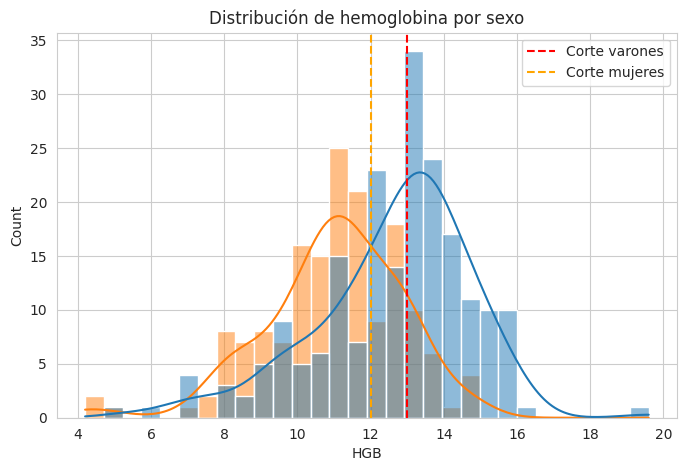

In [7]:
!mkdir -p "{CARPETA}/figures"

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=df, x="HGB", hue="Sex", bins=30, kde=True, ax=ax)
ax.axvline(13, color="red", linestyle="--", label="Corte varones")
ax.axvline(12, color="orange", linestyle="--", label="Corte mujeres")
ax.set_title("Distribución de hemoglobina por sexo")
ax.legend()
plt.savefig(f"{CARPETA}/figures/hgb_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()

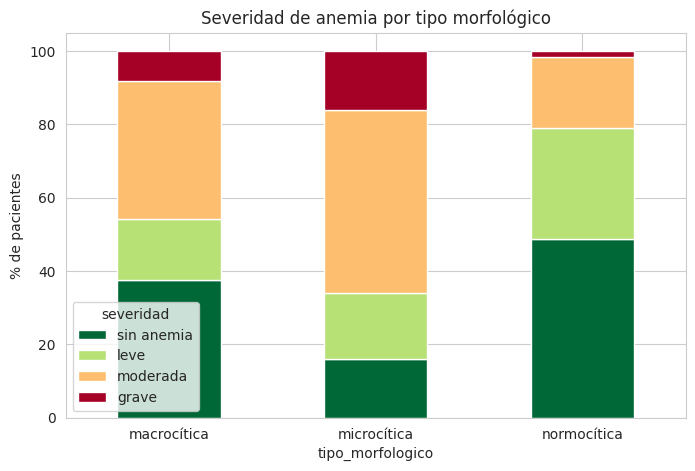

In [8]:
tabla = pd.crosstab(df["tipo_morfologico"], df["severidad"], normalize="index") * 100
tabla = tabla[["sin anemia","leve","moderada","grave"]]
tabla.plot(kind="bar", stacked=True, figsize=(8,5), colormap="RdYlGn_r")
plt.ylabel("% de pacientes")
plt.title("Severidad de anemia por tipo morfológico")
plt.xticks(rotation=0)
plt.savefig(f"{CARPETA}/figures/severidad_por_tipo.png", dpi=150, bbox_inches="tight")
plt.show()

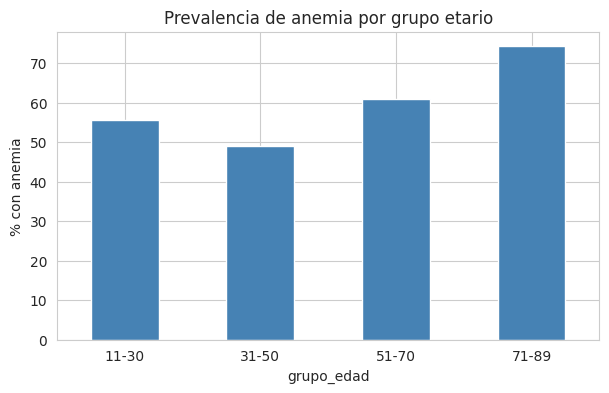

In [9]:
prevalencia_edad = df.groupby("grupo_edad", observed=True)["anemia"].mean() * 100
prevalencia_edad.plot(kind="bar", figsize=(7,4), color="steelblue")
plt.ylabel("% con anemia")
plt.title("Prevalencia de anemia por grupo etario")
plt.xticks(rotation=0)
plt.savefig(f"{CARPETA}/figures/prevalencia_edad.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Guardar dataset procesado para el notebook de modelado
!mkdir -p "{CARPETA}/data"
df.to_csv(f"{CARPETA}/data/anemia_procesado.csv", index=False)
print("Guardado:", df.shape)

Guardado: (364, 16)
